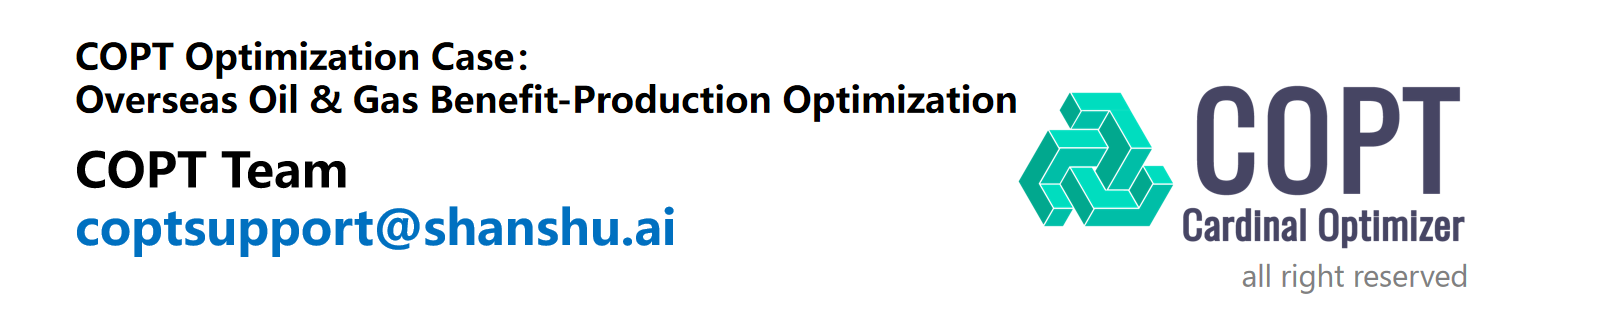

# Overseas Oil & Gas Benefit-Production Optimization: Code Implementation
## Steps to Model and Solve the Problem Using COPT's Multi-Objective Framework

1. **Install Dependencies (Optional)**

2. **Import COPT-Python API** `coptpy`

3. **Add Model Data**
    - Load per-field parameters for the 40 fields from `fields.csv`
    - The constraint threshold parameters from `model_params.csv`.

4. **Create COPT Solving Environment and Model**

5. **Build the model and add the three elements of the model in sequence**
    - **Decision Variables**：
        - $x_{ij}\in\{0,1\}$: whether to develop field $j$ of block $i$;
        - $\delta\geq 0$: auxiliary variable, linearizes the yield-deviation objective $|Q^*-\sum q|$
    - **Objective Function**：
        - Maximize yield
        - Minimize yield deviation
        - Maximize profit
        - Maximize cash flow
        - Minimize composite risk
    - **Constraints**：
        - Unit operating-cost ceiling
        - Unit cash-cost ceiling
        - Total-investment cap
        - Develop at least $n_{i}$ fields per block

6. **Solve**

7. View and analyze solution **results**


This model selects a development subset from 40 candidate fields (5 blocks × 8 fields), using COPT's native multi-objective framework `setObjectiveN` to jointly optimize 5 objectives — yield, yield-deviation, profit, cash flow, and risk — subject to unit-cost ceilings, a total-investment cap, and per-block minimum-count constraints.

In [ ]:
# Fetch this case's data files when they are not already next to the notebook.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/en/Overseas_Oil_Gas_Benefit_Production_Optimization/'
FILES = [
    'fields.csv',
    'model_params.csv',
    'requirements.txt',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')

## Install Dependencies
Run the cell below to install this case's requirements into the runtime. No environment switch or kernel change is needed.

In [3]:
# No conda here; install this case's requirements with pip
!pip install -q -r requirements.txt

## Import COPT-Python API

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coptpy as cp
from coptpy import COPT, quicksum

## Add Model Data

Load per-field parameters (yield, costs, profit, cash flow, risk, etc.) for the 40 fields from `fields.csv`, and the constraint threshold parameters from `model_params.csv`.

In [7]:
fields = pd.read_csv('fields.csv')
params = pd.read_csv('model_params.csv', index_col=0).squeeze()

# Field indices and per-field parameter dictionary
IJ     = [(int(r.block_i), int(r.field_j)) for r in fields.itertuples()]
BLOCKS = sorted(fields['block_i'].unique())
DATA   = {(int(r.block_i), int(r.field_j)): r for r in fields.itertuples()}

C7    = float(params['C7'])                 # total-investment cap
N_REQ = int(params['n_required_per_block']) # min fields to develop per block

print(f"Number of fields: {len(IJ)}   Number of blocks: {len(BLOCKS)}")
print(f"Total production pool: {fields['q'].sum()/1e6:.1f} M tons")
print(f"Total profit pool: {fields['p'].sum()/1e8:.1f} x10^8 CNY")

Number of fields: 40   Number of blocks: 5
Total production pool: 50.3 M tons
Total profit pool: 1875.7 x10^8 CNY


## Create the COPT Environment and COPT Model

Also read the constraint thresholds: $C_2$ (unit operating-cost ceiling), $C_3$ (unit cash-cost ceiling), and $Q^*$ (target yield).

In [9]:
C2       = float(params['C2'])        # unit operating-cost ceiling, CNY/ton
C3       = float(params['C3'])        # unit cash-cost ceiling, CNY/ton
Q_target = float(params['Q_target'])  # target yield, tons

env   = cp.Envr(cp.EnvrConfig().set('nobanner', '1'))
model = env.createModel('oil_multiobj')

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables

$x_{ij}\in\{0,1\}$ indicates whether to develop field $j$ of block $i$; the auxiliary variable $\delta\geq 0$ linearizes the yield-deviation objective $|Q^*-\sum q|$ (the two linearizing inequalities appear in the Constraints section).

In [11]:
# Binary decision variables: develop or not
x = {(i,j): model.addVar(vtype=COPT.BINARY, name=f'x_{i}_{j}') for i,j in IJ}

# Auxiliary variable: linearize objective (1*)  |Q_target - sum q|
dv    = model.addVar(lb=0, name='delta_yield')
q_sum = quicksum(x[i,j] * DATA[i,j].q for i,j in IJ)

### Set Objective Function

Use `model.setObjectiveN(idx, expr, sense)` to register 5 linear objectives at once, then use `setObjParamN` to configure each objective's priority / weight / tolerance.

- Maximize yield: $ \max \sum_{i,j} x_{ij}\,q_{ij} \qquad\text{(1)}$
- Minimize yield deviation: $ \min \delta \quad\text{s.t.}\ \delta \geq Q^{*}-\sum_{i,j}x_{ij}q_{ij},\ \ \delta \geq \sum_{i,j}x_{ij}q_{ij}-Q^{*} \qquad\text{(1*)}$
- Maximize profit: $ \max \sum_{i,j} x_{ij}\,p_{ij} \qquad\text{(2)}$
- Maximize cash flow: $ \max \sum_{i,j} x_{ij}\,c_{ij} \qquad\text{(3)}$
- Minimize composite risk: $ \min \sum_{i,j} x_{ij}\,r_{ij} \qquad\text{(6)}$

In [13]:
# ── Objective expressions ──
p_sum = quicksum(x[i,j] * DATA[i,j].p for i,j in IJ)
c_sum = quicksum(x[i,j] * DATA[i,j].c for i,j in IJ)
r_sum = quicksum(x[i,j] * DATA[i,j].r for i,j in IJ)

# ── Register 5 objectives (idx=0..4) ──
model.setObjectiveN(0, q_sum, COPT.MAXIMIZE)   # (1)  maximize yield
model.setObjectiveN(1, dv,    COPT.MINIMIZE)   # (1*) minimize yield deviation
model.setObjectiveN(2, p_sum, COPT.MAXIMIZE)   # (2)  maximize profit
model.setObjectiveN(3, c_sum, COPT.MAXIMIZE)   # (3)  maximize cash flow
model.setObjectiveN(4, r_sum, COPT.MINIMIZE)   # (6)  minimize risk

# ── Priority example: profit-first -> risk-second -> equal-weight rest ──
# larger priority is optimized first; objectives at the same priority are weight-summed
model.setObjParamN(2, "MultiObjPriority", 2)         # profit: highest priority
model.setObjParamN(4, "MultiObjPriority", 1)         # risk: second priority
# objectives 0,1,3 keep default priority=0, a separate tier from risk

# Absolute tolerance for profit: allow deviating 5e8 CNY from optimal profit,
# leaving room to optimize risk
model.setObjParamN(2, "MultiObjAbsTol", 5e8)

print("Objective priority configuration:")
print("  idx=2 profit  priority=2  AbsTol=5e8 CNY (small profit sacrifice for lower risk)")
print("  idx=4 risk    priority=1")
print("  idx=0,1,3     priority=0  (equal-weight sum)")

Objective priority configuration:
  idx=2 profit  priority=2  AbsTol=5e8 CNY (small profit sacrifice for lower risk)
  idx=4 risk    priority=1
  idx=0,1,3     priority=0  (equal-weight sum)


<font color=#0000FF>
<b>Tip: COPT Multi-Objective Framework setObjectiveN</b>
</font>

COPT registers multiple objectives via `model.setObjectiveN(idx, expr, sense)` and lets you configure each objective's solving strategy with `model.setObjParamN(idx, param, value)`:

| Parameter | Meaning | Default |
|---|---|---|
| `MultiObjPriority` | **Priority**; larger is optimized first. Same-priority objectives are weight-summed; a higher-priority objective is optimized first, then lower ones within an allowed tolerance | `0` |
| `MultiObjWeight` | **Weight**, relative weight among same-priority objectives (can be negative) | `1.0` |
| `MultiObjAbsTol` | **Absolute tolerance**, how far a higher-priority objective may deviate from its optimum, leaving room for lower ones | `1e-6` |
| `MultiObjRelTol` | **Relative tolerance**, like AbsTol but proportional | `0.0` |

**Typical use: hierarchical (lexicographic) optimization** — set the most important objective to the highest priority; the solver optimizes it to optimality first, then continues optimizing the next objective within the allowed tolerance, and so on.

### Add Constraints

Includes the yield-deviation linearization (1*), unit operating-cost ceiling (8), unit cash-cost ceiling (9), total-investment cap (13), and per-block minimum count (14). The fractional objectives (4)(5) have been equivalently converted into constraints (8)(9).

- Absolute-value linearization: $\delta \geq \left|\,Q^{*}- \sum_{i,j} x_{ij}q_{ij}\,\right| \qquad\text{(1*)}$
- Unit operating-cost ceiling: $ \sum_{i,j} x_{ij}\bigl(o_{ij}-C_2\,q_{ij}\bigr) \leq 0 \qquad\text{(8)}$
- Unit cash-cost ceiling: $ \sum_{i,j} x_{ij}\bigl[(o_{ij}+m_{ij}+s_{ij}+e_{ij})-C_3\,q_{ij}\bigr] \leq 0 \qquad\text{(9)}$
- Total-investment cap: $ \sum_{i,j} x_{ij}\,i_{ij} \leq C_7 \qquad\text{(13)}$
- Develop at least $n_{i}$ fields per block: $ \sum_{j} x_{ij} \geq n_i,\quad \forall i \qquad\text{(14)}$

In [15]:
# (1*) Absolute-value linearization: dv >= |Q_target - sum q|
model.addConstr(dv >= Q_target - q_sum, name='dev_pos')
model.addConstr(dv >= q_sum - Q_target, name='dev_neg')

# (8) unit operating-cost ceiling
model.addConstr(
    quicksum(x[i,j] * (DATA[i,j].o - C2 * DATA[i,j].q) for i,j in IJ) <= 0,
    name='constr_8'
)
# (9) unit cash-cost ceiling
model.addConstr(
    quicksum(x[i,j] * (DATA[i,j].o + DATA[i,j].m + DATA[i,j].s + DATA[i,j].e
                       - C3 * DATA[i,j].q) for i,j in IJ) <= 0,
    name='constr_9'
)
# (13) total-investment cap
model.addConstr(
    quicksum(x[i,j] * DATA[i,j].i for i,j in IJ) <= C7, name='constr_13'
)
# (14) at least N_REQ fields per block
for bi in BLOCKS:
    model.addConstr(
        quicksum(x[i,j] for i,j in IJ if i == bi) >= N_REQ, name=f'block_{bi}'
    )

## Solve

In [17]:
print("Solving...")
model.solve()
print(f"Solve status: {model.status}  (1=OPTIMAL)")

Solving...
Model fingerprint: 1f56f1d8

Start the multi-objective optimization with 5 objectives

Using hierarchy method for 3 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    10 rows, 41 columns and 242 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    7 rows, 40 columns and 120 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,2e+09]
    Range of rhs coefficients:       [1e+00,2e+10]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [8e+08,2e+10]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntIn

## Retrieve Results

Read back each objective's realized value from the model and summarize the selected fields' yield, profit, risk, and unit-cost metrics.

In [19]:
# ── Extract solution ──
assert model.status == COPT.OPTIMAL, "Solve failed, please check constraint parameters"

sel_set = {(i,j) for i,j in IJ if x[i,j].x > 0.5}
sel     = fields[fields.apply(
    lambda r: (int(r.block_i), int(r.field_j)) in sel_set, axis=1)]

q_val    = sel['q'].sum()
o_val    = sel['o'].sum()
omse_val = (sel['o'] + sel['m'] + sel['s'] + sel['e']).sum()

# Realized value of each objective (read back from the model)
obj_labels = ['(1) yield', '(1*) yield dev', '(2) profit', '(3) cash flow', '(6) risk']
obj_vals   = [model.getAttrN(k, COPT.Attr.ObjVal) for k in range(5)]

print("=" * 55)
print("Solution summary")
print("=" * 55)
for lab, val in zip(obj_labels, obj_vals):
    print(f"  {lab:<14}: {val:.4e}")
print("-" * 55)
print(f"  Fields selected : {len(sel_set)}")
print(f"  Total yield     : {q_val/1e6:.2f} M tons")
print(f"  Total profit    : {sel['p'].sum()/1e8:.2f} x10^8 CNY")
print(f"  Composite risk  : {sel['r'].sum():.1f}")
print(f"  Unit oper. cost : {o_val/q_val:.1f} CNY/ton  (ceiling C2={C2:.0f})")
print(f"  Unit cash cost  : {omse_val/q_val:.1f} CNY/ton  (ceiling C3={C3:.0f})")
print("=" * 55)

Solution summary
  (1) yield     : 3.5425e+07
  (1*) yield dev: 4.7843e+06
  (2) profit    : 1.3346e+11
  (3) cash flow : 1.3499e+11
  (6) risk      : 1.1686e+03
-------------------------------------------------------
  Fields selected : 26
  Total yield     : 35.42 M tons
  Total profit    : 1334.64 x10^8 CNY
  Composite risk  : 1168.6
  Unit oper. cost : 276.2 CNY/ton  (ceiling C2=350)
  Unit cash cost  : 519.1 CNY/ton  (ceiling C3=520)
